# **Scratch Implementation of SVM**

**`This implementation optimizes the primal objective using gradient descent. Scikit-learn's SVC instead solves the dual optimization problem using algorithms such as SMO.`**

In [53]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [54]:
class SVM:

    def __init__(self , learning_rate , C , epochs):
        self.learning_rate = learning_rate
        self.C = C
        self.epochs = epochs

        self.w = None
        self.b = None


    def fit(self, X_train, y_train):

        n_samples, n_features = X_train.shape

        self.w = np.zeros(n_features)
        self.b = 0

        self.loss_history = []
        self.epoch_history = []

        for epoch in range(self.epochs):

            total_loss = 0

            for idx, x_i in enumerate(X_train):

                # Decision Score
                z = np.dot(x_i, self.w) + self.b

                # Margin
                margin = y_train[idx] * z

                # Hinge Loss
                hinge_loss = max(0, 1 - margin)

                # Cost for current sample
                J = (0.5 * np.linalg.norm(self.w) ** 2) + (self.C * hinge_loss)

                total_loss += J

                # Gradients
                if margin >= 1: #Point is correctly classified and outside the margin. So hinge loss = 0.
                    dw = self.w
                    db = 0
                else:   # margin < 1 Point is either : inside the margin || or misclassified
                    dw = self.w - self.C * y_train[idx] * x_i
                    db = -self.C * y_train[idx]

                # Update
                self.w -= self.learning_rate * dw
                self.b -= self.learning_rate * db

            # Average Cost of Current Epoch
            avg_loss = total_loss / n_samples

            # Store Every 100 Epochs
            if epoch % 100 == 0:
                self.loss_history.append(avg_loss)
                self.epoch_history.append(epoch)

    def predict(self , X_test):
        pred = X_test @ self.w + self.b
        return np.where(pred >= 0, 1, 0) # The decision score is almost never exactly -1.

    def decision_func(self , X_test):
        pred = X_test @ self.w + self.b
        return pred



In [55]:
raw = load_breast_cancer(as_frame=True)
df = raw.frame
df.head(10)

X = df.drop('target' , axis = 1)
y = df['target']

y_numpy = np.array(y)
y_numpy = np.where(y == 0 , -1 ,1)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_numpy,
    shuffle=True,
    stratify=y_numpy,
    random_state=42
)

scaler = StandardScaler(with_std=True , with_mean=True)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = SVM(
    learning_rate = 0.001,
    epochs = 10000,
    C = 1.0
)
model.fit(X_train , y_train)
y_pred = model.predict(X_test)

res = np.where(y_test >= 0, 1, 0)



In [56]:
acc = accuracy_score(res , y_pred)
print(f"Accuracy : {acc * 100: .2f}")

Accuracy :  94.41


**` It implements gradient descent for finding value of " w " and " b " for fundamental..It is just implemented for Learning`**

Margin = y(wᵀx+b)

Case 1:
margin ≥ 1

Loss = 0

Only regularization affects w.

dw = w
db = 0

------------------------

Case 2:
margin < 1

Loss > 0

Regularization + hinge loss affect w.

dw = w − C y x
db = −C y

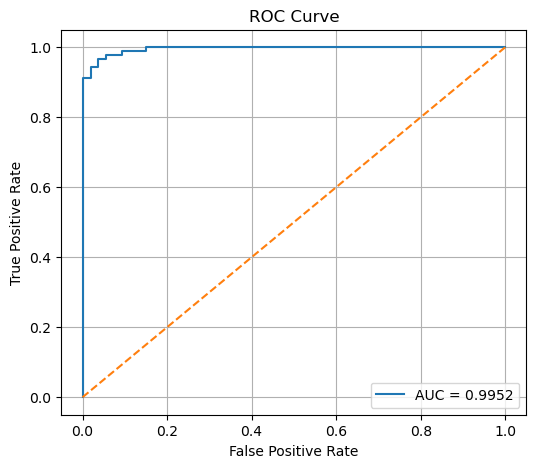

In [60]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Decision scores
y_score =  model.decision_func(X_test)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_score)

# AUC
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()